# Analytic Guazzotto–Freidberg equilibrium

Solov'ev equilibria take $p'$ and $FF'$ constant. That makes them exact, but it
also leaves the pressure gradient and the toroidal current density with a jump
at the plasma edge. Guazzotto and Freidberg (J. Plasma Phys. **87**, 905870303,
2021, Part 1) take the free functions quadratic in the flux instead:

$$p = p_0\psi^2,\qquad F^2 = R_0^2B_0^2\left(1 + 2\frac{\delta B}{B_0}\psi^2\right),$$

so $p$, $p'$ and $J_\phi$ all vanish on the surface ($\psi = 0$). The
Grad–Shafranov equation becomes linear and homogeneous, so it is an
**eigenvalue problem**. In $R = R_0\sqrt{1+\varepsilon^2+2\varepsilon x}$ and
$Z = ay$, the eigenvalue $\alpha$ fixes the axis flux $\Psi_0$. The solution
is a sum of 7 separable terms (12 for an up-down asymmetric single null),
with the separation constants of the paper's Eq. (3.3) and radial functions
given by rapidly converging power series (Appendix A). The shape is imposed by
the flux, slope and curvature at the midplane and top points, or at an X-point.

Only four inputs fix the flux surfaces: $\varepsilon$, $\kappa$, $\delta$ (or
$\kappa_X$, $\delta_X$) and $\nu \approx \beta_p$. The global quantities then
follow once the axis beta $\beta_0$ is fixed, or equivalently the safety
factor on axis $q_0$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from vaft.process.equilibrium import (
    evaluate_guazzotto_freidberg, guazzotto_freidberg_parameters,
    guazzotto_freidberg_to_equilibrium, solve_guazzotto_freidberg, solovev_example,
)
from vaft.plot.analytic import plot_solovev_equilibrium

# Table 4 of the paper (q0 = 1): inputs and the published (beta_T, beta_P, l_i, q95, q*, alpha).
table = {
    "circle":               (("limited", 0.33, 1.0, 0.0, None, None, 1.0),  (0.014, 1, 1.04, 3.21, 2.88, 2.38)),
    "ellipse":              (("limited", 0.25, 2.0, 0.0, None, None, 1.0),  (0.018, 1, 0.85, 3.32, 3.04, 1.88)),
    "elongated D (d=0.6)*": (("limited", 0.33, 1.8, 0.6, None, None, 0.3),  (0.0084, 0.27, 0.85, 3.84, 2.90, 1.96)),
    "high-triangularity D": (("limited", 0.4, 2.0, 0.75, None, None, 1.0),  (0.024, 1, 0.91, 6.82, 4.71, 2.05)),
    "inverse D":            (("limited", 0.33, 1.9, -0.6, None, None, 0.5), (0.014, 0.49, 0.97, 3.12, 3.08, 1.91)),
    "double null":          (("double_null", 0.33, None, None, 2.0, 0.5, 0.4),  (0.011, 0.38, 0.86, 3.74, 2.65, 1.96)),
    "double null, ST":      (("double_null", 0.75, None, None, 2.4, 0.8, 1.04), (0.041, 1.05, 0.97, 18.2, 5.57, 1.90)),
    "single null":          (("lower_single_null", 0.33, 1.6, 0.4, 2.0, 0.5, 1.0), (0.020, 1, 0.93, 4.45, 3.05, 2.04)),
    "single null, high bp": (("lower_single_null", 0.25, 1.8, 0.6, 2.1, 0.8, 2.1), (0.018, 2.16, 1.00, 6.17, 3.71, 2.09)),
}
models = {}
print(f"{'case':22s} {'beta_T':>13s} {'beta_P':>11s} {'l_i':>11s} {'q95':>11s} {'q*':>11s} {'alpha':>11s}")
for name, ((topology, eps, kappa, delta, kx, dx, nu), published) in table.items():
    models[name] = solve_guazzotto_freidberg(topology, inverse_aspect_ratio=eps, nu=nu, elongation=kappa,
                                             triangularity=delta, x_point_elongation=kx, x_point_triangularity=dx)
    got = guazzotto_freidberg_parameters(models[name], q0=1.0)
    cells = [f"{got[k]:.3g}/{v:g}" for k, v in zip(("beta_t", "beta_p", "li", "q95", "q_star", "alpha"), published)]
    print(f"{name:22s} " + " ".join(f"{c:>11s}" for c in cells))
print("(computed/published)")


case                          beta_T      beta_P         l_i         q95          q*       alpha


circle                 0.0137/0.014         1/1   1.04/1.04   3.18/3.21   2.87/2.88   2.38/2.38


ellipse                0.0181/0.018         1/1  0.852/0.85   3.33/3.32   3.04/3.04   1.88/1.88


elongated D (d=0.6)*   0.00826/0.0084  0.274/0.27  0.847/0.85   3.83/3.84     2.9/2.9   1.96/1.96


high-triangularity D   0.0244/0.024         1/1  0.914/0.91   6.84/6.82   4.71/4.71   2.05/2.05


inverse D              0.0138/0.014  0.494/0.49  0.866/0.97   3.12/3.12   3.07/3.08   1.91/1.91


double null            0.0107/0.011  0.376/0.38  0.862/0.86   3.74/3.74    2.8/2.65   1.96/1.96


double null, ST        0.0412/0.041   1.05/1.05  0.974/0.97   18.2/18.2   6.25/5.57     1.9/1.9


single null            0.0202/0.02         1/1   0.93/0.93   4.44/4.45   3.21/3.05   2.04/2.04


single null, high bp   0.0177/0.018   2.16/2.16         1/1    6.2/6.17   3.94/3.71   2.09/2.09
(computed/published)


Eight of the nine rows reproduce the paper to its printed precision, and the
eigenvalue agrees to all printed digits. Three published values do not, and
each is pinned in `test/test_guazzotto_freidberg.py`:

1. **Elongated D.** Table 1 and Fig. 3 give $\delta = 0.4$, but the Table 4 row
   is reproduced completely with $\delta = 0.6$, as done above.
   $\delta = 0.4$ gives $\alpha = 1.921$ and $q_{95} = 3.44$ instead.
2. **Inverse D, $l_i$.** Every other column matches; the paper prints 0.97
   where the solution gives 0.87.
3. **Divertor $q_*$.** The paper uses "$\kappa = \kappa_{95}$" without defining it.
   The elongation of the $\psi = 0.05$ surface gives $q_*$ 5–12 % above the
   table, while the other columns of those rows match.

One more reading choice: Eq. (5.4 h, i) prints the single-null X-point
conditions at $(-\delta_X, -\kappa_X)$. The implementation uses the X-point
$(-x_X, -\kappa_X)$ of Eq. (5.3 d), which is the reading that reproduces the
single-null rows.

## A VEST-like shape in all three topologies

The same machinery at VEST's aspect ratio ($R_0 = 0.4$ m, $a = 0.235$ m), with
$\nu = 0.5$ and $q_0 = 1$. The exported record is an ordinary
`EquilibriumData` in COCOS 11, so VAFT's own plotting and topology tools apply
to it. The red line is the plasma boundary, and the X-points found on the grid are marked.

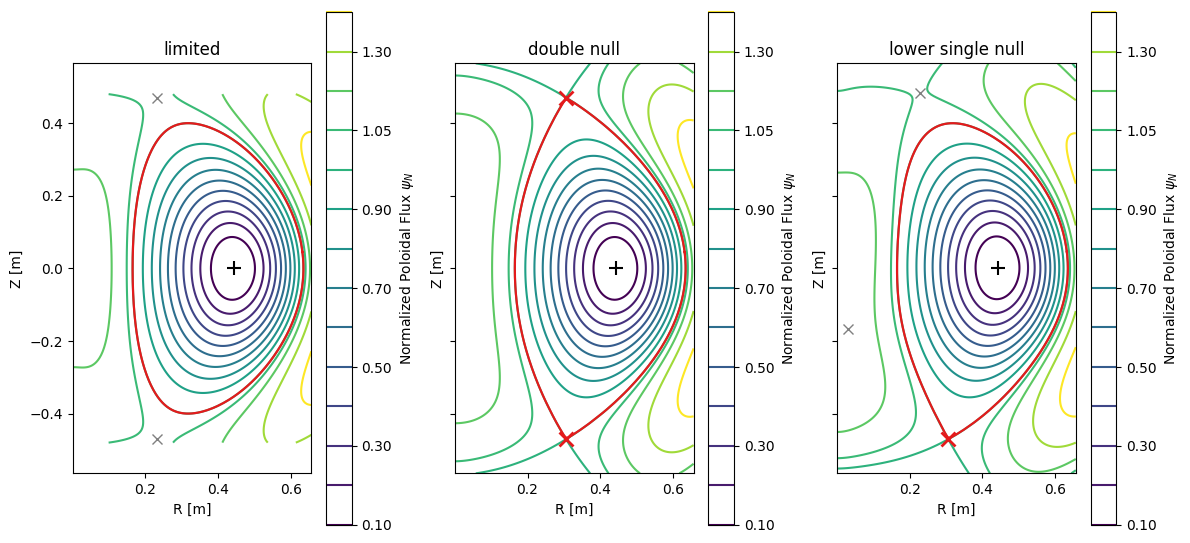

limited            alpha=1.8980  Ip= 42.73 kA  beta_p=0.442  l_i=0.848  q95=5.49
double_null        alpha=1.9044  Ip= 42.45 kA  beta_p=0.444  l_i=0.844  q95=5.69
lower_single_null  alpha=1.9010  Ip= 42.60 kA  beta_p=0.443  l_i=0.846  q95=5.58


In [ ]:
eps_v = 0.235 / 0.4
vest = {
    "limited": solve_guazzotto_freidberg("limited", inverse_aspect_ratio=eps_v, nu=0.5, elongation=1.7, triangularity=0.35),
    "double_null": solve_guazzotto_freidberg("double_null", inverse_aspect_ratio=eps_v, nu=0.5,
                                             x_point_elongation=2.0, x_point_triangularity=0.4),
    "lower_single_null": solve_guazzotto_freidberg("lower_single_null", inverse_aspect_ratio=eps_v, nu=0.5,
                                                   elongation=1.7, triangularity=0.35,
                                                   x_point_elongation=2.0, x_point_triangularity=0.4),
}
exported = {t: guazzotto_freidberg_to_equilibrium(m, major_radius=0.4, toroidal_field=0.1, resolution=161)
            for t, m in vest.items()}
fig, axes = plt.subplots(1, 3, figsize=(12, 5.6), sharey=True)
for ax, (topology, eq_t) in zip(axes, exported.items()):
    plot_solovev_equilibrium(eq_t, ax=ax, title=topology.replace("_", " "))
fig.tight_layout(); plt.show()
for topology, eq_t in exported.items():
    par = eq_t.metadata["parameters"]
    print(f"{topology:18s} alpha={vest[topology].alpha:.4f}  Ip={eq_t.ip/1e3:6.2f} kA  beta_p={par['beta_p']:.3f}  "
          f"l_i={par['li']:.3f}  q95={par['q95']:.2f}")


## What the modified source buys over Solov'ev

On the midplane, the Guazzotto–Freidberg pressure and current density go to
zero at the surface. A Solov'ev equilibrium of the same shape keeps a finite
pressure gradient and current density there.

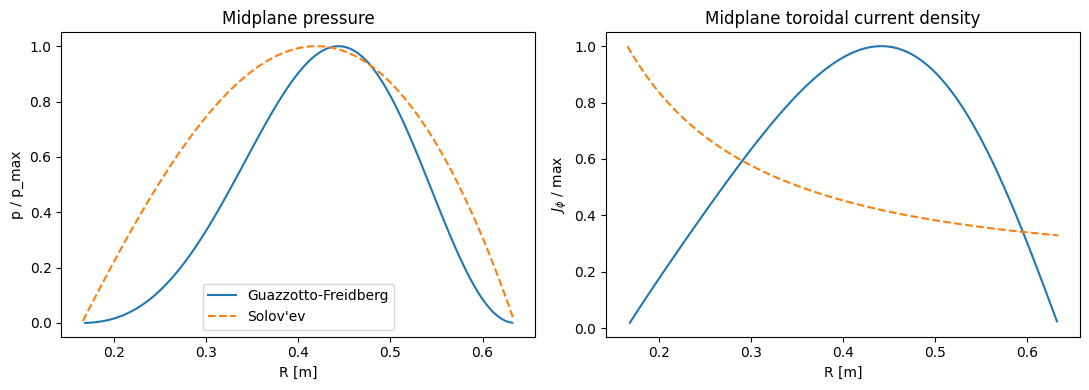

In [ ]:
gf = exported["limited"]
sv = solovev_example("limited", major_radius=0.4, aspect_ratio=1/eps_v, elongation=1.7, triangularity=0.35,
                     plasma_current=gf.ip, toroidal_field=0.1)

def midplane(eq):
    from scipy.constants import mu_0
    j_index = int(np.argmin(np.abs(eq.z - eq.magnetic_axis[1])))
    psi_n = (eq.psi[:, j_index] - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis)
    order = np.argsort((eq.psi_1d - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis))
    grid = ((eq.psi_1d - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis))[order]
    inside = (psi_n >= 0) & (psi_n <= 1)
    p = np.where(inside, np.interp(psi_n, grid, eq.pressure[order]), np.nan)
    pp = np.interp(psi_n, grid, eq.pprime[order]); ff = np.interp(psi_n, grid, eq.ffprime[order])
    j = np.where(inside, -2 * np.pi * (eq.r * pp + ff / (mu_0 * eq.r)), np.nan)
    return eq.r, p / np.nanmax(p), j / np.nanmax(np.abs(j))

fig, (p_ax, j_ax) = plt.subplots(1, 2, figsize=(11, 4))
for eq_m, label, style in ((gf, "Guazzotto-Freidberg", "C0-"), (sv, "Solov'ev", "C1--")):
    r, p, j = midplane(eq_m)
    p_ax.plot(r, p, style, label=label); j_ax.plot(r, j, style, label=label)
p_ax.set(xlabel="R [m]", ylabel="p / p_max", title="Midplane pressure")
j_ax.set(xlabel="R [m]", ylabel=r"$J_\phi$ / max", title="Midplane toroidal current density")
p_ax.legend(); fig.tight_layout(); plt.show()


## $\nu$ as the poloidal-beta knob

$\nu = \mu_0p_0/(\mu_0p_0 + B_0\delta B/(1+\varepsilon^2))$ is the only source
input that changes the flux surfaces, and the paper shows $\nu \approx \beta_p$.
Above $\nu_{\max} = 1/\hat\varepsilon$ the inboard current reverses, and the
solver refuses that range.

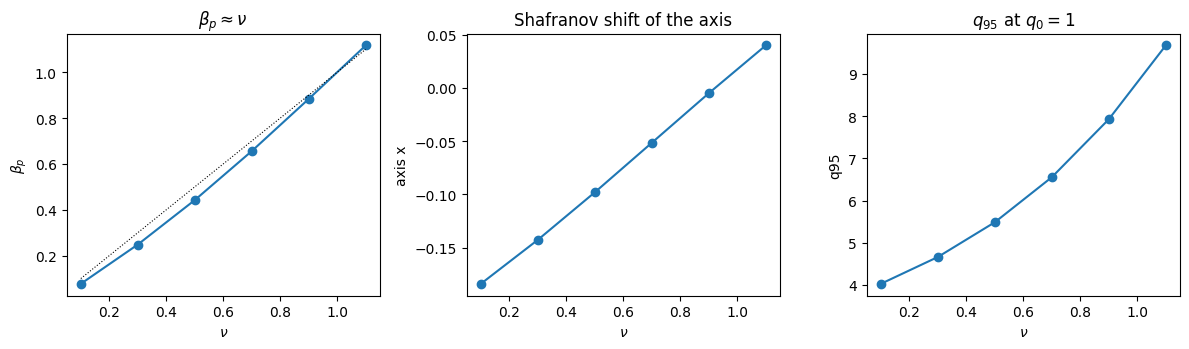

nu_max = 1/eps_hat = 1.145
nu = 1.3: nonphysical current reversal: nu=1.3 exceeds nu_max = 1/eps_hat = 1.145 (Eq. 2.10)


In [ ]:
nus = np.linspace(0.1, 1.1, 6)
rows = []
for nu in nus:
    m = solve_guazzotto_freidberg("limited", inverse_aspect_ratio=eps_v, nu=nu, elongation=1.7, triangularity=0.35)
    par = guazzotto_freidberg_parameters(m, q0=1.0)
    rows.append((nu, m.alpha, par["beta_p"], par["li"], par["q95"], m.magnetic_axis[0]))
rows = np.array(rows)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].plot(rows[:, 0], rows[:, 2], "o-"); axes[0].plot(rows[:, 0], rows[:, 0], "k:", lw=0.8)
axes[0].set(xlabel=r"$\nu$", ylabel=r"$\beta_p$", title=r"$\beta_p \approx \nu$")
axes[1].plot(rows[:, 0], rows[:, 5], "o-"); axes[1].set(xlabel=r"$\nu$", ylabel="axis x", title="Shafranov shift of the axis")
axes[2].plot(rows[:, 0], rows[:, 4], "o-"); axes[2].set(xlabel=r"$\nu$", ylabel="q95", title=r"$q_{95}$ at $q_0 = 1$")
fig.tight_layout(); plt.show()
eps_hat = 2 * eps_v / (1 + eps_v**2)
print(f"nu_max = 1/eps_hat = {1/eps_hat:.3f}")
try:
    solve_guazzotto_freidberg("limited", inverse_aspect_ratio=eps_v, nu=1.3, elongation=1.7, triangularity=0.35)
except ValueError as error:
    print("nu = 1.3:", error)
